# Battery Degradation Dataset — Initial Data Processing
## Team Kansas Capstone: Predictive Maintenance for Aircraft Readiness

**Author**: Prem G  
**Dataset**: NASA PCoE Battery Aging Dataset  
**Date**: March 2026  

---

## Why Battery Data Matters for This Project

Our capstone goal is to build an **Intelligent Flight Readiness Prediction System (IFRPM)** — a system that tells airlines whether an aircraft is safe to fly based on health of its components, weather conditions, and operational factors.

**The battery dataset plays a critical role**: Aircraft rely on Li-ion batteries for avionics, emergency systems, and auxiliary power. A degraded battery is a safety risk. By modeling battery degradation:

1. We can predict **Remaining Useful Life (RUL)** — how many more charge-discharge cycles before the battery fails
2. We can compute **State of Health (SOH)** — how healthy the battery is relative to when it was new
3. These feed into the project's **composite Health Index**, which combines with engine health (CMAPSS) and flight records (NGAFID) for the final go/no-go decision

---

## Dataset Overview

The NASA PCoE Battery Aging dataset contains **38 Li-ion battery cells** (labeled B0005–B0056) that were cycled to end-of-life under controlled lab conditions. Each battery was charged and discharged repeatedly while measurements were recorded, giving us a complete degradation history.

**Data is stored as `.mat` (MATLAB) files** — we'll parse them into CSV format for our ML pipeline.

| Experiment Group | Batteries | Temperature | Discharge Profile |
|-----------------|-----------|-------------|-------------------|
| FY08Q4 | B0005–B0007, B0018 | Room (~24°C) | 2A constant current |
| 25–44 (24°C) | B0025–B0028, B0033–B0034, B0036 | 24°C | Varies |
| 25–44 (43°C) | B0029–B0032 | 43°C (elevated) | 4A constant current |
| 25–44 (mixed) | B0038–B0044 | 24°C/4°C | Varies |
| 45–48 | B0045–B0048 | 4°C (cold) | 1A constant current |
| 49–52 | B0049–B0052 | 4°C (cold) | 2A (incomplete) |
| 53–56 | B0053–B0056 | 4°C (cold) | 2A constant current |

Testing different temperatures is valuable because **cold weather degrades batteries faster** — exactly the kind of environmental stress factor that connects to our weather API data.

---
## Section 1: Library Imports and Setup

In [1]:
# Standard library
import os
import warnings
from datetime import datetime

# Scientific computing
import numpy as np
import scipy.io as sio
import scipy.stats as stats

# Data manipulation
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('tab10')

print('All libraries loaded successfully.')
print(f'NumPy: {np.__version__} | Pandas: {pd.__version__}')

All libraries loaded successfully.
NumPy: 1.26.4 | Pandas: 2.2.2


---
## Section 2: Data Loading

The dataset is organized into 6 folders. Important notes before loading:

- **Folder 2 is SKIPPED** — batteries B0025–B0028 appear in both Folder 2 and Folder 3. They are byte-for-byte identical. We use Folder 3 as the canonical source.
- We load all `.mat` files using `scipy.io.loadmat()` with `simplify_cells=True`, which converts MATLAB structs into clean Python dicts — otherwise the nested MATLAB format is very difficult to work with.
- Each `.mat` file contains one battery's full cycle history.

In [2]:
# Base path to dataset (relative to this notebook's location)
BASE_PATH = '5. Battery Data Set'

# Folder definitions — Folder 2 is skipped (duplicates folder 3's B0025-28)
FOLDERS = [
    '1. BatteryAgingARC-FY08Q4',
    # '2. BatteryAgingARC_25_26_27_28_P1',   # SKIPPED: duplicates folder 3
    '3. BatteryAgingARC_25-44',
    '4. BatteryAgingARC_45_46_47_48',
    '5. BatteryAgingARC_49_50_51_52',
    '6. BatteryAgingARC_53_54_55_56',
]

# Load all .mat files
all_batteries = {}   # { 'B0005': [list of cycle dicts], ... }
battery_folder_map = {}  # track which folder each battery came from

for folder in FOLDERS:
    folder_path = os.path.join(BASE_PATH, folder)
    mat_files = sorted([f for f in os.listdir(folder_path) if f.endswith('.mat')])
    
    for fname in mat_files:
        battery_id = fname.replace('.mat', '')  # e.g. 'B0005'
        full_path = os.path.join(folder_path, fname)
        
        # simplify_cells=True converts MATLAB cell arrays/structs to Python lists/dicts
        mat = sio.loadmat(full_path, simplify_cells=True)
        
        # Each .mat file has the battery ID as the top-level key
        # The battery object has a 'cycle' field which is a list of cycle dicts
        cycles = mat[battery_id]['cycle']
        
        all_batteries[battery_id] = cycles
        battery_folder_map[battery_id] = folder

print(f'Total batteries loaded: {len(all_batteries)}')
print()

# Summary table
summary_rows = []
for bid, cycles in sorted(all_batteries.items()):
    n_discharge = sum(1 for c in cycles if c['type'] == 'discharge')
    n_charge    = sum(1 for c in cycles if c['type'] == 'charge')
    n_impedance = sum(1 for c in cycles if c['type'] == 'impedance')
    summary_rows.append({
        'battery_id': bid,
        'folder': battery_folder_map[bid][:30],
        'total_cycles': len(cycles),
        'discharge_cycles': n_discharge,
        'charge_cycles': n_charge,
        'impedance_cycles': n_impedance,
    })

df_summary_load = pd.DataFrame(summary_rows)
print(df_summary_load.to_string(index=False))

Total batteries loaded: 34

battery_id                         folder  total_cycles  discharge_cycles  charge_cycles  impedance_cycles
     B0005      1. BatteryAgingARC-FY08Q4           616               168            170               278
     B0006      1. BatteryAgingARC-FY08Q4           616               168            170               278
     B0007      1. BatteryAgingARC-FY08Q4           616               168            170               278
     B0018      1. BatteryAgingARC-FY08Q4           319               132            134                53
     B0025       3. BatteryAgingARC_25-44            80                28             31                21
     B0026       3. BatteryAgingARC_25-44            80                28             31                21
     B0027       3. BatteryAgingARC_25-44            80                28             31                21
     B0028       3. BatteryAgingARC_25-44            80                28             31                21
     B002

---
## Section 3: Data Parsing — Discharge Cycles

Each cycle in the `.mat` file has a `type` field: `'charge'`, `'discharge'`, or `'impedance'`.  
We care most about **discharge cycles** because:

- The **Capacity** field (Ahr delivered per discharge) is our primary health indicator — it drops as the battery ages
- Voltage and current profiles during discharge reveal how the battery responds under load
- Temperature during discharge shows how the battery heats up

We extract **per-discharge-cycle summary statistics** (not the full time-series arrays) — this gives us one clean row per cycle per battery.

In [3]:
def parse_datevec(time_val):
    """
    Convert MATLAB datevec [year, month, day, hour, minute, second] to Python datetime.
    Returns None if the value is malformed.
    """
    try:
        t = np.array(time_val).flatten()
        return datetime(int(t[0]), int(t[1]), int(t[2]),
                        int(t[3]), int(t[4]), int(min(t[5], 59)))
    except Exception:
        return None


def safe_scalar(val):
    """
    Safely extract a float scalar from a value that may be a Python float,
    a 0-d numpy array, a 1-element array, or an empty array (returns NaN).
    Some cycles (e.g. B0050 crashed cycles) store Capacity as an empty array
    instead of a scalar — this handles that gracefully.
    """
    arr = np.array(val).flatten()
    if len(arr) >= 1:
        return float(arr[0])
    return np.nan


discharge_rows = []

for battery_id, cycles in sorted(all_batteries.items()):
    discharge_num = 0  # count only discharge cycles per battery
    
    for cycle_idx, cycle in enumerate(cycles):
        if cycle['type'] != 'discharge':
            continue
        
        discharge_num += 1
        data = cycle['data']
        
        # --- Extract time-series arrays ---
        # Some arrays may be 1D or 2D depending on MATLAB format; flatten for safety
        voltage  = np.array(data.get('Voltage_measured', [])).flatten()
        current  = np.array(data.get('Current_measured', [])).flatten()
        temp_meas= np.array(data.get('Temperature_measured', [])).flatten()
        time_arr = np.array(data.get('Time', [])).flatten()
        
        # Capacity: total charge delivered this discharge cycle (Ahr)
        # Use safe_scalar because some crashed cycles store this as an empty array
        capacity = safe_scalar(data.get('Capacity', np.nan))
        
        # Compute per-cycle summary statistics (only if arrays are non-empty)
        min_voltage  = float(np.min(voltage))   if len(voltage) > 0  else np.nan
        max_voltage  = float(np.max(voltage))   if len(voltage) > 0  else np.nan
        avg_voltage  = float(np.mean(voltage))  if len(voltage) > 0  else np.nan
        avg_current  = float(np.mean(current))  if len(current) > 0  else np.nan
        avg_temp     = float(np.mean(temp_meas))if len(temp_meas) > 0 else np.nan
        duration_sec = float(time_arr[-1] - time_arr[0]) if len(time_arr) > 1 else np.nan
        
        discharge_rows.append({
            'battery_id':          battery_id,
            'cycle_index':         cycle_idx,           # position in raw cycle list
            'discharge_cycle_num': discharge_num,        # 1-based discharge counter
            'ambient_temperature': float(cycle.get('ambient_temperature', np.nan)),
            'date':                parse_datevec(cycle.get('time', [])),
            'capacity_ahr':        capacity,
            'min_voltage':         min_voltage,
            'max_voltage':         max_voltage,
            'avg_voltage':         avg_voltage,
            'avg_current':         avg_current,
            'avg_temp_measured':   avg_temp,
            'duration_seconds':    duration_sec,
        })

df_discharge = pd.DataFrame(discharge_rows)

print('Discharge DataFrame shape:', df_discharge.shape)
print()
print('Data types:')
print(df_discharge.dtypes)
print()
print('First 10 rows:')
df_discharge.head(10)

Discharge DataFrame shape: (2794, 12)

Data types:
battery_id                     object
cycle_index                     int64
discharge_cycle_num             int64
ambient_temperature           float64
date                   datetime64[ns]
capacity_ahr                  float64
min_voltage                   float64
max_voltage                   float64
avg_voltage                   float64
avg_current                   float64
avg_temp_measured             float64
duration_seconds              float64
dtype: object

First 10 rows:


,battery_id,cycle_index,discharge_cycle_num,ambient_temperature,date,capacity_ahr,min_voltage,max_voltage,avg_voltage,avg_current,avg_temp_measured,duration_seconds
0,B0005,1,1,24.0000,2008-04-02 15:25:41,1.8565,2.6125,4.1915,3.5298,-1.8187,32.5723,3690.2340
1,B0005,3,2,24.0000,2008-04-02 19:43:48,1.8463,2.5872,4.1898,3.5373,-1.8176,32.7252,3672.3440
2,B0005,5,3,24.0000,2008-04-03 00:01:06,1.8353,2.6519,4.1882,3.5437,-1.8165,32.6429,3651.6410
3,B0005,7,4,24.0000,2008-04-03 04:16:37,1.8353,2.5929,4.1885,3.5437,-1.8256,32.5149,3631.5630
4,B0005,9,5,24.0000,2008-04-03 08:33:25,1.8346,2.5474,4.1883,3.5423,-1.8261,32.3823,3629.1720
5,B0005,11,6,24.0000,2008-04-03 12:55:10,1.8357,2.5209,4.1888,3.5413,-1.8168,32.4342,3652.2810
6,B0005,13,7,24.0000,2008-04-03 17:17:16,1.8351,2.4879,4.1884,3.5410,-1.8168,32.4804,3650.8280
7,B0005,15,8,24.0000,2008-04-03 21:28:14,1.8258,2.6652,4.1889,3.5541,-1.8443,32.4105,3572.4530
8,B0005,17,9,24.0000,2008-04-04 01:38:15,1.8248,2.6039,4.1890,3.5529,-1.8540,32.3461,3550.5940
9,B0005,19,10,24.0000,2008-04-04 05:48:08,1.8246,2.5529,4.1892,3.5512,-1.8536,32.2768,3551.2500


---
## Section 4: Data Parsing — Impedance Cycles

Every ~20 charge/discharge cycles, an **Electrochemical Impedance Spectroscopy (EIS)** measurement is taken. This sweeps an AC signal across frequencies (0.1 Hz to 5 kHz) and measures how the battery resists current flow.

**Why this matters for RUL prediction:**
- **Re (electrolyte resistance)** increases as the electrolyte degrades — a direct aging indicator
- **Rct (charge transfer resistance)** increases as electrode surfaces corrode — another aging indicator
- These features are harder to measure on a plane but make the RUL model more accurate and robust

We'll merge impedance features with discharge features later in feature engineering.

In [4]:
impedance_rows = []

for battery_id, cycles in sorted(all_batteries.items()):
    impedance_num = 0
    
    for cycle_idx, cycle in enumerate(cycles):
        if cycle['type'] != 'impedance':
            continue
        
        impedance_num += 1
        data = cycle['data']
        
        # Each impedance field may be an array (one value per frequency)
        # We take the mean across frequencies for a single summary value
        Re  = np.array(data.get('Re',  [])).flatten()
        Rct = np.array(data.get('Rct', [])).flatten()
        batt_imp = np.array(data.get('Battery_impedance',    [])).flatten()
        rect_imp = np.array(data.get('Rectified_Impedance',  [])).flatten()
        
        impedance_rows.append({
            'battery_id':              battery_id,
            'cycle_index':             cycle_idx,
            'impedance_cycle_num':     impedance_num,
            'ambient_temperature':     float(cycle.get('ambient_temperature', np.nan)),
            'date':                    parse_datevec(cycle.get('time', [])),
            'Re_mean':                 float(np.mean(Re))       if len(Re) > 0      else np.nan,
            'Rct_mean':                float(np.mean(Rct))      if len(Rct) > 0     else np.nan,
            'battery_impedance_mean':  float(np.mean(batt_imp)) if len(batt_imp) > 0 else np.nan,
            'rectified_impedance_mean':float(np.mean(rect_imp)) if len(rect_imp) > 0 else np.nan,
        })

df_impedance = pd.DataFrame(impedance_rows)

print('Impedance DataFrame shape:', df_impedance.shape)
print()
print('First 10 rows:')
df_impedance.head(10)

Impedance DataFrame shape: (1956, 9)

First 10 rows:


,battery_id,cycle_index,impedance_cycle_num,ambient_temperature,date,Re_mean,Rct_mean,battery_impedance_mean,rectified_impedance_mean
0,B0005,40,1,24.0000,2008-04-18 20:55:29,0.0447,0.0695,0.1719,0.0592
1,B0005,42,2,24.0000,2008-04-18 22:39:16,0.0467,0.0763,0.1713,0.0606
2,B0005,44,3,24.0000,2008-04-19 02:14:27,0.0448,0.0680,0.1715,0.0586
3,B0005,46,4,24.0000,2008-04-19 03:57:24,0.0462,0.0745,0.1706,0.0598
4,B0005,48,5,24.0000,2008-04-19 07:32:33,0.0451,0.0685,0.1720,0.0592
5,B0005,50,6,24.0000,2008-04-19 09:15:10,0.0460,0.0734,0.1692,0.0592
6,B0005,52,7,24.0000,2008-04-19 12:47:00,0.0442,0.0680,0.1723,0.0590
7,B0005,54,8,24.0000,2008-04-19 14:28:58,0.0452,0.0746,0.1704,0.0597
8,B0005,56,9,24.0000,2008-04-19 18:12:47,0.0438,0.0685,0.1720,0.0588
9,B0005,58,10,24.0000,2008-04-19 19:55:05,0.0449,0.0740,0.1696,0.0592


---
## Section 5: Data Cleaning

### What issues do we expect?

From reading the README files and dataset documentation, we know about several data quality problems:

| Battery | Issue | Root Cause |
|---------|-------|------------|
| B0041 | Near-zero capacity (~0.05 Ahr) | Voltage cutoff hit instantly at 4°C — battery too cold |
| B0033 | First few cycles anomalous (0.068 Ahr) | Initialization issue — normal behavior resumes by cycle 7 |
| B0036 | One cycle reads 2.44 Ahr (impossible) | Sensor/measurement artifact |
| B0049–B0052 | Very few cycles | Control software crash — experiment ended prematurely |

We'll detect these using both **domain knowledge** (impossible values) and **statistical methods** (IQR-based outlier detection), then flag them rather than deleting them — this preserves data for analysis.

In [5]:
# --- Step 1: Check for missing values ---
print('=== Missing Value Report ===')
null_counts = df_discharge.isnull().sum()
print(null_counts[null_counts > 0] if null_counts.sum() > 0 else 'No missing values found.')
print()

=== Missing Value Report ===
capacity_ahr    25
dtype: int64



In [6]:
# --- Step 2: Outlier detection on capacity_ahr ---
# Method 1: Statistical — IQR (3x bounds)
# Method 2: Domain knowledge — physically impossible values
#
# IQR = Interquartile Range (Q3 - Q1). Values beyond 3×IQR from Q1/Q3 are extreme outliers.
# We use 3×IQR (not standard 1.5×) because battery capacity naturally varies across batteries.
# However, with this mixed dataset, the IQR bounds may be wide — so we ALSO apply
# domain knowledge checks for physically impossible values:
#   - Capacity = 0.0 Ahr → experiment didn't run (voltage cutoff hit instantly)
#   - Capacity > 2.2 Ahr → impossible for a 2.0 Ahr rated battery (sensor artifact)

Q1 = df_discharge['capacity_ahr'].quantile(0.25)
Q3 = df_discharge['capacity_ahr'].quantile(0.75)
IQR = Q3 - Q1

lower_iqr = Q1 - 3 * IQR
upper_iqr = Q3 + 3 * IQR

# Domain knowledge bounds (physically impossible for 2.0 Ahr cells)
DOMAIN_LOWER = 0.01   # < 10 mAhr: effectively zero, experiment failed
DOMAIN_UPPER = 2.2    # > 2.2 Ahr: impossible for 2.0 Ahr rated battery

print(f'IQR bounds (statistical):      [{lower_iqr:.4f}, {upper_iqr:.4f}] Ahr')
print(f'Domain bounds (physics-based): [{DOMAIN_LOWER}, {DOMAIN_UPPER}] Ahr')
print()

# Combine: flag as outlier if either method catches it
iqr_flag    = (df_discharge['capacity_ahr'] < lower_iqr) | (df_discharge['capacity_ahr'] > upper_iqr)
domain_flag = (df_discharge['capacity_ahr'] < DOMAIN_LOWER) | (df_discharge['capacity_ahr'] > DOMAIN_UPPER)

df_discharge['is_outlier'] = iqr_flag | domain_flag
df_discharge['outlier_reason'] = ''
df_discharge.loc[iqr_flag,    'outlier_reason'] = 'IQR statistical'
df_discharge.loc[domain_flag, 'outlier_reason'] = 'Domain knowledge'
df_discharge.loc[iqr_flag & domain_flag, 'outlier_reason'] = 'Both'

print(f'Outlier cycles flagged (IQR):         {iqr_flag.sum()}')
print(f'Outlier cycles flagged (Domain):      {domain_flag.sum()}')
print(f'Total flagged (either):               {df_discharge["is_outlier"].sum()} out of {len(df_discharge)}')
print()
print('Flagged cycles by battery:')
flagged = df_discharge[df_discharge['is_outlier']][['battery_id','discharge_cycle_num','capacity_ahr','outlier_reason']]
print(flagged.groupby(['battery_id','outlier_reason'])['discharge_cycle_num'].count().rename('count').reset_index().to_string(index=False))

IQR bounds (statistical):      [-0.4198, 3.2437] Ahr
Domain bounds (physics-based): [0.01, 2.2] Ahr

Outlier cycles flagged (IQR):         0
Outlier cycles flagged (Domain):      23
Total flagged (either):               23 out of 2794

Flagged cycles by battery:
battery_id   outlier_reason  count
     B0036 Domain knowledge      1
     B0042 Domain knowledge      1
     B0043 Domain knowledge      1
     B0044 Domain knowledge      1
     B0045 Domain knowledge      2
     B0046 Domain knowledge      3
     B0047 Domain knowledge      3
     B0048 Domain knowledge      3
     B0049 Domain knowledge      2
     B0050 Domain knowledge      2
     B0051 Domain knowledge      2
     B0053 Domain knowledge      1
     B0054 Domain knowledge      1


In [7]:
# --- Step 3: Mark right-censored batteries ---
# 'Right-censored' means the battery experiment ended before the battery reached end-of-life.
# B0049-B0052: control software crashed; these batteries have very few discharge cycles.
# For RUL modeling, censored data is still useful but we must label it so the model knows
# the true EOL was NOT observed.

CENSORED_BATTERIES = {'B0049', 'B0050', 'B0051', 'B0052'}

df_discharge['is_censored'] = df_discharge['battery_id'].isin(CENSORED_BATTERIES)

print('Censored battery cycle counts:')
print(df_discharge[df_discharge['is_censored']].groupby('battery_id')['discharge_cycle_num'].max())
print()
print('Non-censored battery cycle counts (max discharge cycles):')
print(df_discharge[~df_discharge['is_censored']].groupby('battery_id')['discharge_cycle_num'].max().sort_values())

Censored battery cycle counts:
battery_id
B0049    25
B0050    25
B0051    25
B0052    25
Name: discharge_cycle_num, dtype: int64

Non-censored battery cycle counts (max discharge cycles):
battery_id
B0025     28
B0026     28
B0027     28
B0028     28
B0032     40
B0029     40
B0030     40
B0031     40
B0040     47
B0039     47
B0038     47
B0053     56
B0041     67
B0046     72
B0048     72
B0045     72
B0047     72
B0055    102
B0056    102
B0054    103
B0042    112
B0043    112
B0044    112
B0018    132
B0005    168
B0007    168
B0006    168
B0033    197
B0034    197
B0036    197
Name: discharge_cycle_num, dtype: int64


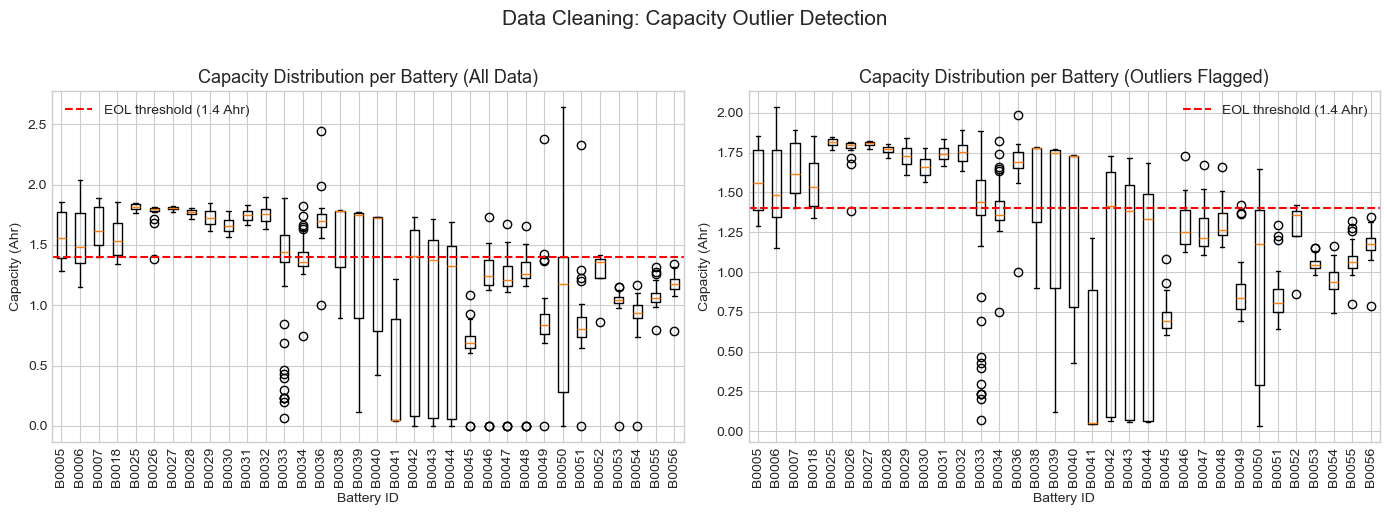

Clean dataset size (outliers flagged, not deleted): 2771 rows


In [8]:
# --- Step 4: Visualize capacity distribution before and after flagging outliers ---

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before: all data
axes[0].boxplot(
    [df_discharge[df_discharge['battery_id']==bid]['capacity_ahr'].dropna()
     for bid in sorted(df_discharge['battery_id'].unique())],
    labels=sorted(df_discharge['battery_id'].unique()),
    vert=True
)
axes[0].set_title('Capacity Distribution per Battery (All Data)', fontsize=13)
axes[0].set_xlabel('Battery ID')
axes[0].set_ylabel('Capacity (Ahr)')
axes[0].tick_params(axis='x', rotation=90)
axes[0].axhline(y=1.4, color='red', linestyle='--', label='EOL threshold (1.4 Ahr)')
axes[0].legend()

# After: exclude flagged outliers
df_clean = df_discharge[~df_discharge['is_outlier']]
axes[1].boxplot(
    [df_clean[df_clean['battery_id']==bid]['capacity_ahr'].dropna()
     for bid in sorted(df_clean['battery_id'].unique())],
    labels=sorted(df_clean['battery_id'].unique()),
    vert=True
)
axes[1].set_title('Capacity Distribution per Battery (Outliers Flagged)', fontsize=13)
axes[1].set_xlabel('Battery ID')
axes[1].set_ylabel('Capacity (Ahr)')
axes[1].tick_params(axis='x', rotation=90)
axes[1].axhline(y=1.4, color='red', linestyle='--', label='EOL threshold (1.4 Ahr)')
axes[1].legend()

plt.suptitle('Data Cleaning: Capacity Outlier Detection', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

print(f'Clean dataset size (outliers flagged, not deleted): {len(df_clean)} rows')

---
## Section 6: Exploratory Data Analysis (EDA)

Now we visualize the data to understand patterns before building features. Good EDA:
- Confirms the data loaded correctly
- Reveals degradation patterns we can exploit in our ML model
- Validates our cleaning steps
- Gives us intuition about which features will be most predictive

### Plot 1: Capacity Fade Curves

**What this shows**: How each battery's capacity drops over cycles.  
**What to look for**: Most batteries should show a smooth downward trend. Steep drops or flat regions indicate anomalies.  
**Why it matters**: This is the core signal our RUL model will learn from.

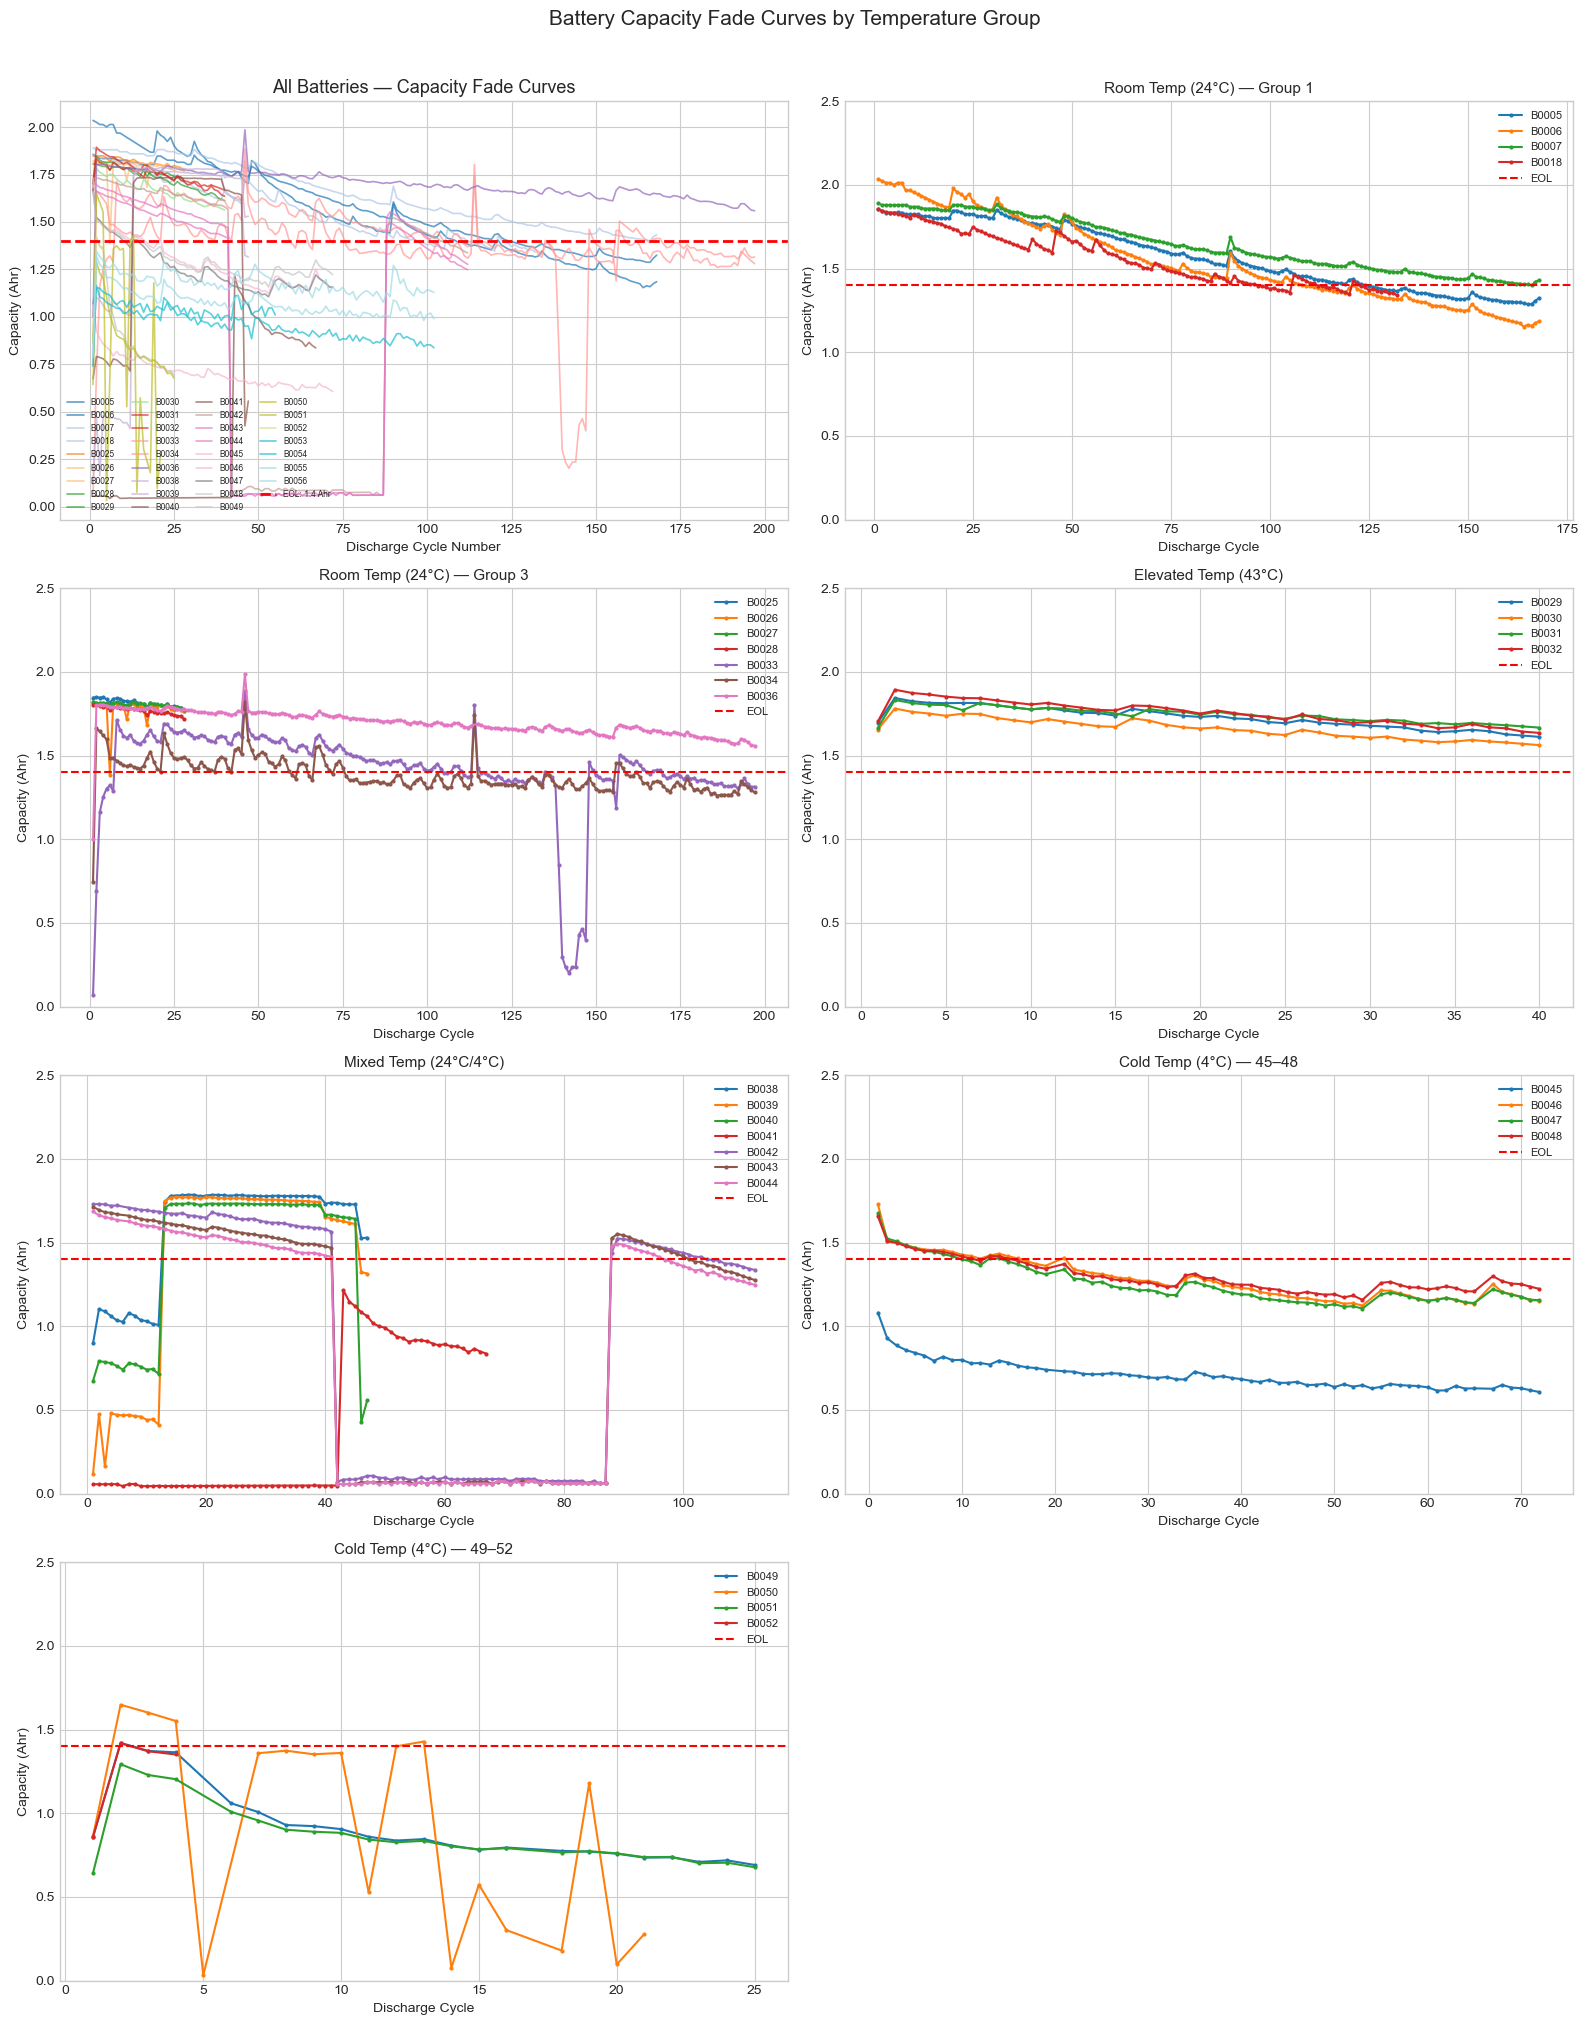

In [9]:
# Group batteries by their temperature group for organized plotting
temp_groups = {
    'Room Temp (24°C) — Group 1': ['B0005', 'B0006', 'B0007', 'B0018'],
    'Room Temp (24°C) — Group 3': ['B0025', 'B0026', 'B0027', 'B0028',
                                    'B0033', 'B0034', 'B0036'],
    'Elevated Temp (43°C)':        ['B0029', 'B0030', 'B0031', 'B0032'],
    'Mixed Temp (24°C/4°C)':       ['B0038', 'B0039', 'B0040',
                                    'B0041', 'B0042', 'B0043', 'B0044'],
    'Cold Temp (4°C) — 45–48':     ['B0045', 'B0046', 'B0047', 'B0048'],
    'Cold Temp (4°C) — 49–52':     ['B0049', 'B0050', 'B0051', 'B0052'],
    'Cold Temp (4°C) — 53–56':     ['B0053', 'B0054', 'B0055', 'B0056'],
}

fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

# Main plot: all batteries together
ax_main = axes[0]
colors = cm.tab20(np.linspace(0, 1, len(all_batteries)))
for i, bid in enumerate(sorted(all_batteries.keys())):
    bdf = df_clean[df_clean['battery_id'] == bid].sort_values('discharge_cycle_num')
    ax_main.plot(bdf['discharge_cycle_num'], bdf['capacity_ahr'],
                 alpha=0.7, linewidth=1.2, label=bid, color=colors[i])
ax_main.axhline(y=1.4, color='red', linestyle='--', linewidth=2, label='EOL: 1.4 Ahr')
ax_main.set_title('All Batteries — Capacity Fade Curves', fontsize=13)
ax_main.set_xlabel('Discharge Cycle Number')
ax_main.set_ylabel('Capacity (Ahr)')
ax_main.legend(fontsize=6, ncol=4, loc='lower left')

# Per-group plots
for j, (group_name, battery_ids) in enumerate(temp_groups.items()):
    ax = axes[j + 1]
    for bid in battery_ids:
        bdf = df_clean[df_clean['battery_id'] == bid].sort_values('discharge_cycle_num')
        if len(bdf) > 0:
            ax.plot(bdf['discharge_cycle_num'], bdf['capacity_ahr'],
                    linewidth=1.5, label=bid, marker='o', markersize=2)
    ax.axhline(y=1.4, color='red', linestyle='--', linewidth=1.5, label='EOL')
    ax.set_title(group_name, fontsize=11)
    ax.set_xlabel('Discharge Cycle')
    ax.set_ylabel('Capacity (Ahr)')
    ax.legend(fontsize=8)
    ax.set_ylim(0, 2.5)

# Hide unused subplot
axes[-1].set_visible(False)

plt.suptitle('Battery Capacity Fade Curves by Temperature Group', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

### Plot 2: Impedance Growth Over Cycles

**What this shows**: How electrolyte resistance (Re) and charge transfer resistance (Rct) grow as the battery ages.  
**Why it matters**: Both Re and Rct increase monotonically with age — they're excellent RUL predictors even when capacity fade is not yet severe. This is analogous to engine vibration signatures in CMAPSS.

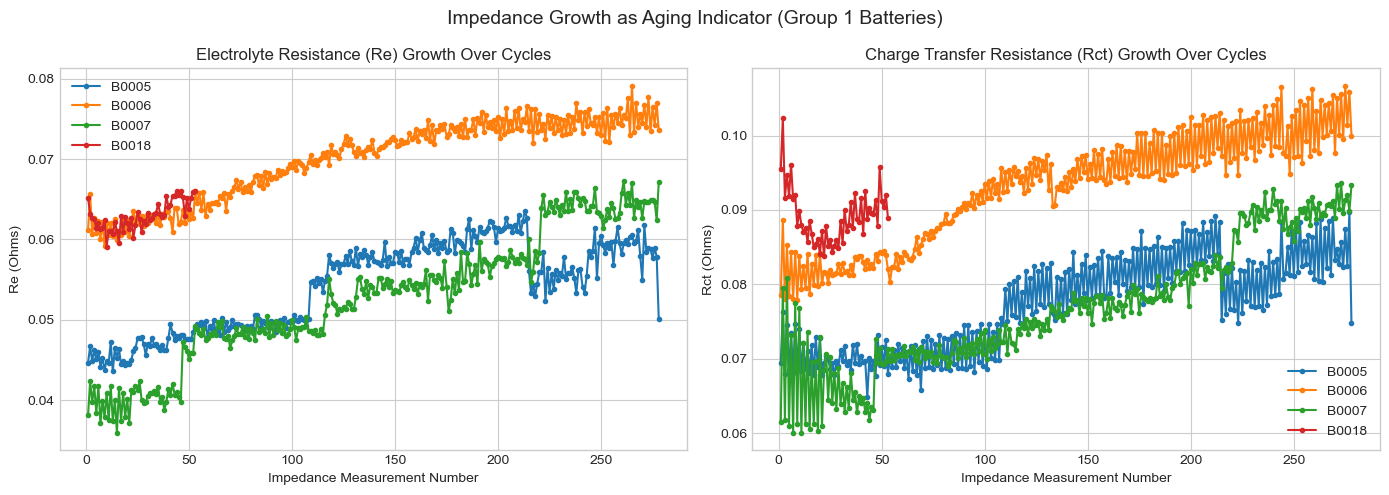

In [10]:
# Focus on Group 1 batteries (B0005-B0018) which have the most complete impedance data
group1_ids = ['B0005', 'B0006', 'B0007', 'B0018']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for bid in group1_ids:
    imp_df = df_impedance[df_impedance['battery_id'] == bid].sort_values('cycle_index')
    if len(imp_df) > 0:
        axes[0].plot(imp_df['impedance_cycle_num'], imp_df['Re_mean'],
                     marker='o', markersize=3, linewidth=1.5, label=bid)
        axes[1].plot(imp_df['impedance_cycle_num'], imp_df['Rct_mean'],
                     marker='o', markersize=3, linewidth=1.5, label=bid)

axes[0].set_title('Electrolyte Resistance (Re) Growth Over Cycles', fontsize=12)
axes[0].set_xlabel('Impedance Measurement Number')
axes[0].set_ylabel('Re (Ohms)')
axes[0].legend()

axes[1].set_title('Charge Transfer Resistance (Rct) Growth Over Cycles', fontsize=12)
axes[1].set_xlabel('Impedance Measurement Number')
axes[1].set_ylabel('Rct (Ohms)')
axes[1].legend()

plt.suptitle('Impedance Growth as Aging Indicator (Group 1 Batteries)', fontsize=14)
plt.tight_layout()
plt.show()

### Plot 3: Temperature Effect on Degradation Rate

**What this shows**: How quickly batteries fade at different ambient temperatures.  
**Key insight**: Cold temperature (4°C) batteries often have lower usable capacity per cycle but may degrade differently than room-temperature batteries. Elevated temperature (43°C) typically accelerates chemical degradation.  
**Connection to weather data**: This relationship lets us use real weather data to adjust our RUL predictions — a cold day means faster effective degradation.

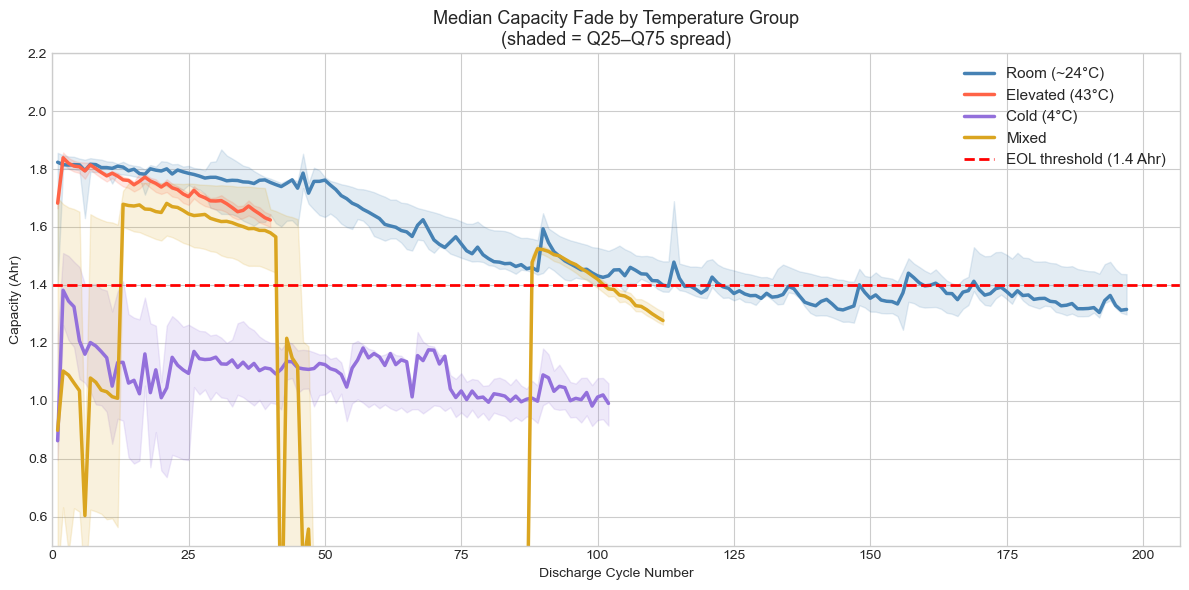

In [11]:
# Assign temperature group label for each row
def assign_temp_group(battery_id):
    groups = {
        'Room (~24°C)': ['B0005','B0006','B0007','B0018',
                         'B0025','B0026','B0027','B0028',
                         'B0033','B0034','B0036'],
        'Elevated (43°C)': ['B0029','B0030','B0031','B0032'],
        'Cold (4°C)':    ['B0045','B0046','B0047','B0048',
                          'B0049','B0050','B0051','B0052',
                          'B0053','B0054','B0055','B0056'],
        'Mixed':         ['B0038','B0039','B0040',
                          'B0041','B0042','B0043','B0044'],
    }
    for label, ids in groups.items():
        if battery_id in ids:
            return label
    return 'Unknown'

df_clean = df_clean.copy()
df_clean['temp_group'] = df_clean['battery_id'].apply(assign_temp_group)

# Plot median capacity fade curves per temperature group
fig, ax = plt.subplots(figsize=(12, 6))

palette = {'Room (~24°C)': 'steelblue', 'Elevated (43°C)': 'tomato',
           'Cold (4°C)': 'mediumpurple', 'Mixed': 'goldenrod'}

for group in ['Room (~24°C)', 'Elevated (43°C)', 'Cold (4°C)', 'Mixed']:
    grp_df = df_clean[df_clean['temp_group'] == group]
    if len(grp_df) == 0:
        continue
    # Median capacity at each cycle number across all batteries in this group
    median_cap = grp_df.groupby('discharge_cycle_num')['capacity_ahr'].median()
    ax.plot(median_cap.index, median_cap.values,
            linewidth=2.5, label=group, color=palette[group])
    # Shaded band for spread
    q25 = grp_df.groupby('discharge_cycle_num')['capacity_ahr'].quantile(0.25)
    q75 = grp_df.groupby('discharge_cycle_num')['capacity_ahr'].quantile(0.75)
    ax.fill_between(median_cap.index, q25, q75,
                    alpha=0.15, color=palette[group])

ax.axhline(y=1.4, color='red', linestyle='--', linewidth=2, label='EOL threshold (1.4 Ahr)')
ax.set_title('Median Capacity Fade by Temperature Group\n(shaded = Q25–Q75 spread)', fontsize=13)
ax.set_xlabel('Discharge Cycle Number')
ax.set_ylabel('Capacity (Ahr)')
ax.legend(fontsize=11)
ax.set_xlim(0)
ax.set_ylim(0.5, 2.2)
plt.tight_layout()
plt.show()

### Plot 4: Initial Capacity Distribution

Not all batteries start at the same capacity. Knowing each battery's initial capacity is essential for computing SOH correctly — we need to measure health **relative to each battery's own starting point**, not a fixed reference.

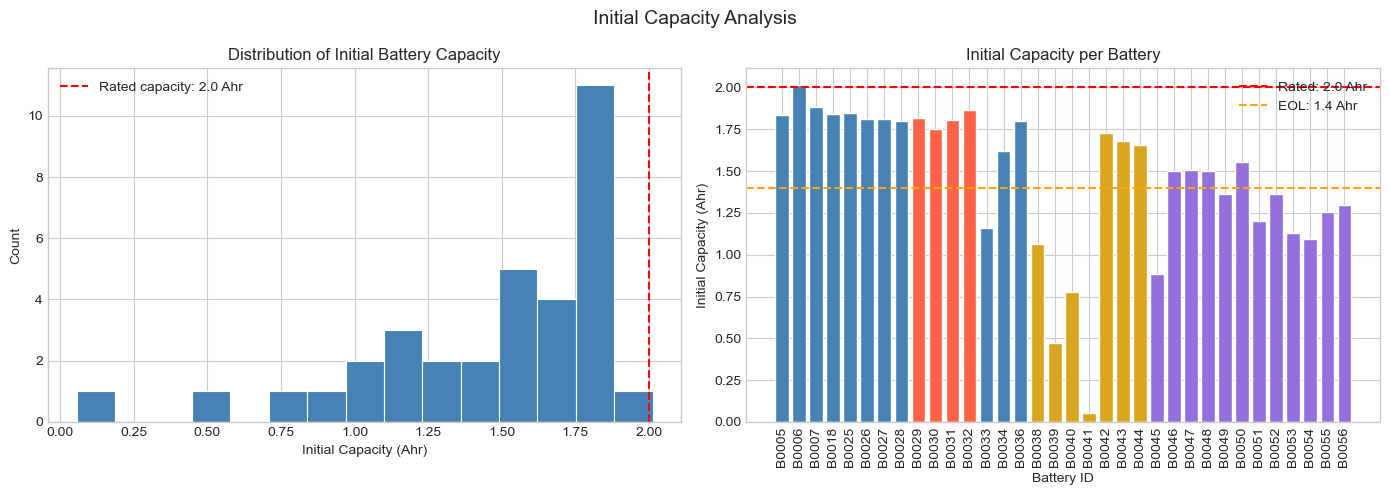

Initial capacity statistics:
count   34.0000
mean     1.4633
std      0.4430
min      0.0558
25%      1.2172
50%      1.5862
75%      1.8118
max      2.0133
Name: initial_capacity, dtype: float64


In [12]:
# Compute initial capacity for each battery (median of first 5 valid cycles)
initial_caps = []
for bid in sorted(all_batteries.keys()):
    bdf = df_clean[df_clean['battery_id'] == bid].sort_values('discharge_cycle_num')
    first_valid = bdf[~bdf['is_outlier']].head(5)
    initial_caps.append({
        'battery_id': bid,
        'initial_capacity': first_valid['capacity_ahr'].median(),
        'temp_group': assign_temp_group(bid),
    })

df_init = pd.DataFrame(initial_caps)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df_init['initial_capacity'].dropna(), bins=15, color='steelblue',
             edgecolor='white', linewidth=0.8)
axes[0].axvline(x=2.0, color='red', linestyle='--', label='Rated capacity: 2.0 Ahr')
axes[0].set_title('Distribution of Initial Battery Capacity', fontsize=12)
axes[0].set_xlabel('Initial Capacity (Ahr)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Per-battery bar
colors_bar = [palette.get(assign_temp_group(bid), 'grey')
              for bid in df_init['battery_id']]
axes[1].bar(df_init['battery_id'], df_init['initial_capacity'],
            color=colors_bar, edgecolor='white')
axes[1].axhline(y=2.0, color='red', linestyle='--', label='Rated: 2.0 Ahr')
axes[1].axhline(y=1.4, color='orange', linestyle='--', label='EOL: 1.4 Ahr')
axes[1].set_title('Initial Capacity per Battery', fontsize=12)
axes[1].set_xlabel('Battery ID')
axes[1].set_ylabel('Initial Capacity (Ahr)')
axes[1].tick_params(axis='x', rotation=90)
axes[1].legend()

plt.suptitle('Initial Capacity Analysis', fontsize=14)
plt.tight_layout()
plt.show()

print('Initial capacity statistics:')
print(df_init['initial_capacity'].describe())

### Plot 5: Correlation Heatmap

**What this shows**: Pairwise linear correlation between all numeric features.  
**What to look for**: Strong correlations with `capacity_ahr` indicate good predictors for RUL. High correlations between features indicate redundancy (we may not need both).

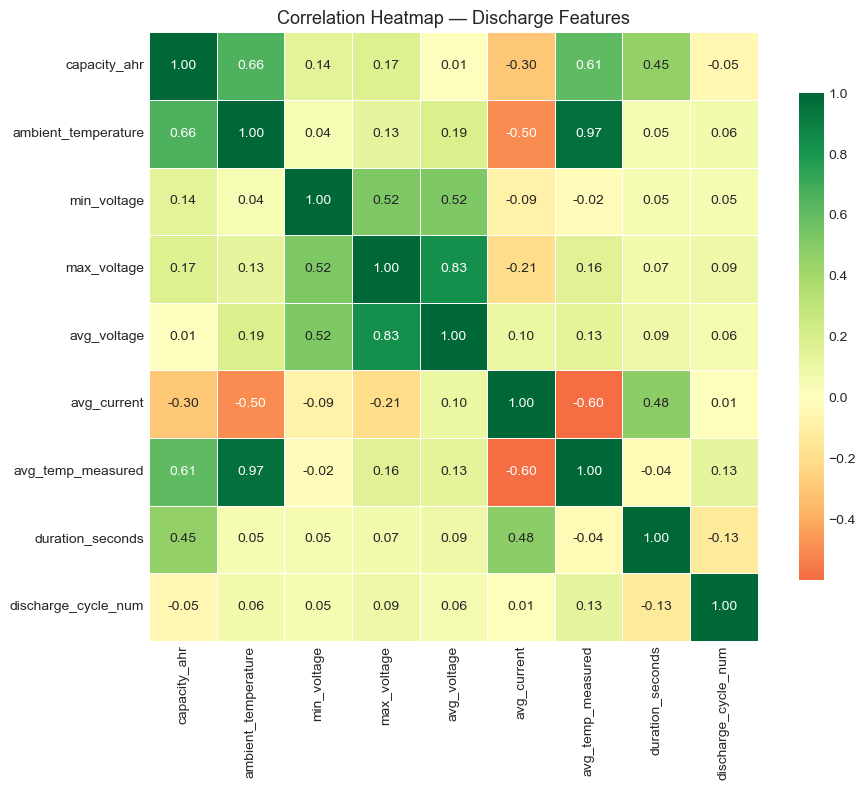

Top correlations with capacity_ahr:
capacity_ahr           1.0000
ambient_temperature    0.6572
avg_temp_measured      0.6126
duration_seconds       0.4512
max_voltage            0.1734
min_voltage            0.1422
avg_voltage            0.0063
discharge_cycle_num   -0.0463
avg_current           -0.2990
Name: capacity_ahr, dtype: float64


In [13]:
numeric_cols = ['capacity_ahr', 'ambient_temperature', 'min_voltage', 'max_voltage',
                'avg_voltage', 'avg_current', 'avg_temp_measured', 'duration_seconds',
                'discharge_cycle_num']

corr_matrix = df_clean[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Correlation Heatmap — Discharge Features', fontsize=13)
plt.tight_layout()
plt.show()

print('Top correlations with capacity_ahr:')
print(corr_matrix['capacity_ahr'].sort_values(ascending=False))

---
## Section 7: Feature Engineering — SOH and RUL

This is the most important step for our ML pipeline. We convert raw measurements into meaningful **predictive features**.

### Features we'll compute:

| Feature | Formula | Why it's useful |
|---------|----------|------------------|
| **SOH** | `capacity / initial_capacity × 100` | Normalized health signal (0–100%) |
| **RUL** | `eol_cycle - current_cycle` | The label we're predicting |
| **capacity_fade_rate** | Rolling slope of last 5 cycles | Rate of degradation — accelerating fade is a warning sign |
| **SOH_rolling_mean** | 5-cycle rolling mean of SOH | Smoothed health signal, removes single-cycle noise |
| **SOH_rolling_std** | 5-cycle rolling std of SOH | Variability in health — increasing std signals instability |
| **temperature_stress_factor** | `ambient_temp / 24.0` | Normalized temperature (1.0 = room temp baseline) |
| **cycle_normalized** | `cycle / eol_cycle` | Fraction of life used (0→1) — position in lifecycle |
| **Re_norm** | `Re / Re_first` | Impedance growth ratio (1.0 at start, grows with age) |
| **Rct_norm** | `Rct / Rct_first` | Charge transfer resistance growth ratio |

In [14]:
EOL_THRESHOLD_AHR = 1.4   # 30% fade from 2.0 Ahr rated capacity

feature_rows = []

for bid in sorted(all_batteries.keys()):
    # Get this battery's discharge data, sorted by cycle
    bdf = df_clean[df_clean['battery_id'] == bid].sort_values('discharge_cycle_num').copy()
    
    if len(bdf) == 0:
        continue
    
    # --- Initial capacity: median of first 3 valid (non-outlier, non-trivial) cycles ---
    # Strategy: take the first 3 cycles where capacity > 0.5 Ahr and not flagged as outlier.
    # This robustly handles:
    #   - B0033's first 7 anomalous cycles (0.068 Ahr) — skipped by the 0.5 Ahr floor
    #   - B0006's slightly-above-rated start (2.035 Ahr) — included, it IS the true initial cap
    first_valid = bdf[(~bdf['is_outlier']) & (bdf['capacity_ahr'] > 0.5)].head(3)
    if len(first_valid) == 0:
        continue
    cap_0 = first_valid['capacity_ahr'].median()
    if cap_0 == 0 or np.isnan(cap_0):
        continue
    
    # --- SOH: State of Health as % of initial capacity ---
    bdf['SOH'] = (bdf['capacity_ahr'] / cap_0) * 100.0
    
    # --- Find EOL cycle: first cycle where capacity drops below EOL threshold ---
    is_censored = bid in CENSORED_BATTERIES
    eol_rows = bdf[bdf['capacity_ahr'] <= EOL_THRESHOLD_AHR]
    
    if len(eol_rows) > 0:
        eol_cycle = int(eol_rows['discharge_cycle_num'].iloc[0])
    else:
        # Battery didn't reach EOL — right-censored: EOL is unknown
        # We use the maximum observed cycle as a lower bound
        eol_cycle = int(bdf['discharge_cycle_num'].max())
        is_censored = True
    
    # --- RUL: Remaining Useful Life in cycles ---
    # For non-censored: RUL = eol_cycle - current_cycle
    # For censored: RUL is clipped to 0 (we know at minimum 0 cycles remain after EOL)
    bdf['RUL'] = eol_cycle - bdf['discharge_cycle_num']
    bdf['RUL'] = bdf['RUL'].clip(lower=0)  # Can't be negative
    bdf['is_censored'] = is_censored
    
    # --- Cycle normalized: fraction of life used (0 = new, 1 = end of life) ---
    bdf['cycle_normalized'] = bdf['discharge_cycle_num'] / eol_cycle
    
    # --- Capacity fade rate: rolling slope over last 5 cycles ---
    # A negative slope means fading (expected). Accelerating negative slope is a warning sign.
    def rolling_slope(series, window=5):
        slopes = [np.nan] * len(series)
        vals = series.values
        for i in range(window - 1, len(vals)):
            x = np.arange(window)
            y = vals[i - window + 1 : i + 1]
            if not np.any(np.isnan(y)):
                slopes[i] = np.polyfit(x, y, 1)[0]  # slope of linear fit
        return slopes
    
    bdf['capacity_fade_rate'] = rolling_slope(bdf['capacity_ahr'])
    
    # --- SOH rolling statistics (window=5) ---
    bdf['SOH_rolling_mean'] = bdf['SOH'].rolling(window=5, min_periods=1).mean()
    bdf['SOH_rolling_std']  = bdf['SOH'].rolling(window=5, min_periods=1).std().fillna(0)
    
    # --- Temperature stress factor: normalized to room temperature baseline ---
    # 24°C = 1.0 (baseline); 4°C ≈ 0.17 (cold stress); 43°C ≈ 1.79 (heat stress)
    bdf['temperature_stress_factor'] = bdf['ambient_temperature'] / 24.0
    
    feature_rows.append(bdf)

df_features = pd.concat(feature_rows, ignore_index=True)

print('Feature DataFrame shape:', df_features.shape)
print()
print('Sample features:')
df_features[['battery_id','discharge_cycle_num','capacity_ahr','SOH',
              'RUL','cycle_normalized','capacity_fade_rate',
              'SOH_rolling_mean','temperature_stress_factor']].head(15)

Feature DataFrame shape: (2771, 23)

Sample features:


,battery_id,discharge_cycle_num,capacity_ahr,SOH,RUL,cycle_normalized,capacity_fade_rate,SOH_rolling_mean,temperature_stress_factor
0,B0005,1,1.8565,100.5503,124,0.0080,NaN,100.5503,1.0000
1,B0005,2,1.8463,100.0000,123,0.0160,NaN,100.2751,1.0000
2,B0005,3,1.8353,99.4054,122,0.0240,NaN,99.9852,1.0000
3,B0005,4,1.8353,99.4007,121,0.0320,NaN,99.8391,1.0000
4,B0005,5,1.8346,99.3673,120,0.0400,-0.0055,99.7447,1.0000
5,B0005,6,1.8357,99.4223,119,0.0480,-0.0022,99.5192,1.0000
6,B0005,7,1.8351,99.3944,118,0.0560,-0.0000,99.3980,1.0000
7,B0005,8,1.8258,98.8859,117,0.0640,-0.0019,99.2941,1.0000
8,B0005,9,1.8248,98.8326,116,0.0720,-0.0030,99.1805,1.0000
9,B0005,10,1.8246,98.8239,115,0.0800,-0.0032,99.0718,1.0000


In [15]:
# --- Merge impedance features ---
# We can't do an exact cycle join because impedance cycles happen every ~20 charge/discharge cycles.
# Strategy: for each discharge cycle, find the closest impedance measurement by cycle_index
# and use a forward-fill merge (most recent impedance reading available at that point).

imp_merged_rows = []

for bid in sorted(all_batteries.keys()):
    dis_bdf = df_features[df_features['battery_id'] == bid].sort_values('cycle_index')
    imp_bdf = df_impedance[df_impedance['battery_id'] == bid].sort_values('cycle_index')
    
    if len(imp_bdf) == 0:
        # No impedance data for this battery — assign NaN
        dis_bdf = dis_bdf.copy()
        dis_bdf['Re_norm']  = np.nan
        dis_bdf['Rct_norm'] = np.nan
        imp_merged_rows.append(dis_bdf)
        continue
    
    # Normalize Re and Rct to their first measurement (growth ratio)
    Re_0  = imp_bdf['Re_mean'].iloc[0]
    Rct_0 = imp_bdf['Rct_mean'].iloc[0]
    
    imp_bdf = imp_bdf.copy()
    imp_bdf['Re_norm']  = imp_bdf['Re_mean']  / Re_0  if Re_0  and Re_0 != 0  else np.nan
    imp_bdf['Rct_norm'] = imp_bdf['Rct_mean'] / Rct_0 if Rct_0 and Rct_0 != 0 else np.nan
    
    # Merge using merge_asof: for each discharge cycle, use the nearest preceding impedance reading
    merged = pd.merge_asof(
        dis_bdf.sort_values('cycle_index'),
        imp_bdf[['cycle_index','Re_norm','Rct_norm']].sort_values('cycle_index'),
        on='cycle_index',
        direction='backward'   # use the most recent impedance measurement
    )
    imp_merged_rows.append(merged)

df_features = pd.concat(imp_merged_rows, ignore_index=True)

print('Features after impedance merge:', df_features.shape)
print()
print('Impedance feature availability:')
print(df_features[['Re_norm','Rct_norm']].isnull().sum())
print()
df_features[['battery_id','discharge_cycle_num','SOH','RUL',
              'Re_norm','Rct_norm']].dropna().head(10)

Features after impedance merge: (2771, 25)

Impedance feature availability:
Re_norm     76
Rct_norm    76
dtype: int64



,battery_id,discharge_cycle_num,SOH,RUL,Re_norm,Rct_norm
19,B0005,20,100.0378,105,1.0000,1.0000
20,B0005,21,100.0590,104,1.0039,0.9786
21,B0005,22,99.4503,103,1.0097,0.9866
22,B0005,23,98.8872,102,0.9889,0.9797
23,B0005,24,98.8510,101,0.9803,0.9855
24,B0005,25,98.8764,100,0.9993,0.9839
25,B0005,26,98.2508,99,0.9752,0.9889
26,B0005,27,98.2908,98,1.0134,0.9811
27,B0005,28,98.2474,97,0.9959,0.9765
28,B0005,29,97.6406,96,0.9943,0.9914


In [16]:
# --- Statistical summary of all engineered features ---
feature_cols = ['capacity_ahr','SOH','RUL','cycle_normalized',
                'capacity_fade_rate','SOH_rolling_mean','SOH_rolling_std',
                'temperature_stress_factor','Re_norm','Rct_norm']

print('Feature Statistics:')
df_features[feature_cols].describe().round(4)

Feature Statistics:


,capacity_ahr,SOH,RUL,cycle_normalized,capacity_fade_rate,SOH_rolling_mean,SOH_rolling_std,temperature_stress_factor,Re_norm,Rct_norm
count,2746.0000,2746.0000,2771.0000,2771.0000,2610.0000,2754.0000,2771.0000,2771.0000,2695.0000,2695.0000
mean,1.3341,86.0039,14.1866,31.3234,-0.0020,86.0011,2.6844,0.7693,-427.9396,998.1907
std,0.4594,31.1485,30.3421,48.3024,0.0487,30.5400,7.3475,0.5131,5891.3982,15902.5959
min,0.0326,2.0328,0.0000,0.0060,-0.4517,3.4265,0.0000,0.1667,-101951.8313,0.4326
25%,1.1561,78.8067,0.0000,0.7735,-0.0081,78.9291,0.4405,0.1667,0.9574,0.8364
50%,1.4290,88.5483,0.0000,3.0000,-0.0037,88.6383,0.8346,1.0000,0.9963,0.9254
75%,1.6738,96.8424,12.0000,45.0000,0.0002,96.6606,1.6422,1.0000,1.0554,1.0724
max,2.0353,220.4638,167.0000,197.0000,0.4454,220.3258,80.6983,1.8333,5713.6989,306382.2440


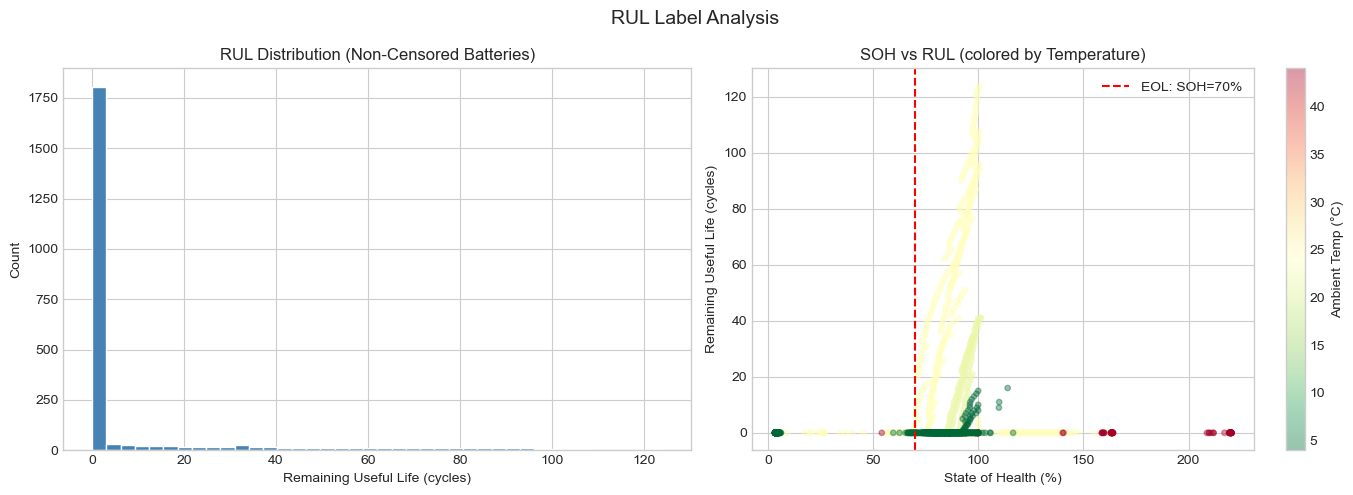

RUL range (non-censored): 0 to 124 cycles
Mean RUL: 9.3 cycles


In [17]:
# --- RUL Distribution Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of RUL values
non_censored = df_features[~df_features['is_censored']]
axes[0].hist(non_censored['RUL'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('RUL Distribution (Non-Censored Batteries)', fontsize=12)
axes[0].set_xlabel('Remaining Useful Life (cycles)')
axes[0].set_ylabel('Count')

# SOH vs RUL scatter
sc = axes[1].scatter(
    non_censored['SOH'], non_censored['RUL'],
    c=non_censored['ambient_temperature'],
    cmap='RdYlGn_r', alpha=0.4, s=15
)
plt.colorbar(sc, ax=axes[1], label='Ambient Temp (°C)')
axes[1].set_title('SOH vs RUL (colored by Temperature)', fontsize=12)
axes[1].set_xlabel('State of Health (%)')
axes[1].set_ylabel('Remaining Useful Life (cycles)')
axes[1].axvline(x=70, color='red', linestyle='--', label='EOL: SOH=70%')
axes[1].legend()

plt.suptitle('RUL Label Analysis', fontsize=14)
plt.tight_layout()
plt.show()

print(f'RUL range (non-censored): {non_censored["RUL"].min():.0f} to {non_censored["RUL"].max():.0f} cycles')
print(f'Mean RUL: {non_censored["RUL"].mean():.1f} cycles')

---
## Section 8: Dependency Analysis — How Battery Data Connects to the Project

### Connection to CMAPSS (Engine Health — Deveshree's dataset)

Both datasets use **RUL as the prediction target**. We've engineered our RUL labels using the same convention:
- RUL = 0 at End of Life
- RUL counts down from the first cycle
- Censored samples are flagged separately

This means our battery RUL features can be **stacked or concatenated** with CMAPSS engine RUL features in a joint model. The composite Health Index can be computed as:
```
Health_Index = w1 × (Battery_SOH) + w2 × (Engine_RUL_normalized) + ...
```

### Connection to Weather API (Jal's dataset)

The `ambient_temperature` column in our dataset is in **°C**, the same unit the Aviation Weather API uses for temperature (METAR reports).  
Our `temperature_stress_factor` feature provides a direct mapping: when live weather data says it's 4°C outside, we know from this dataset that battery degradation per cycle is significantly different than at 24°C.  
This creates a **dynamic RUL adjustment** based on real weather conditions.

### Connection to NGAFID (Kavish's dataset)

No direct feature join — but our SOH threshold (70%) can trigger the same kind of **maintenance flag** that NGAFID maintenance logs record. If `SOH < 80%`, that maps to a maintenance-needed alert in the NGAFID-style maintenance code taxonomy.

### What features our ML teammates need from this dataset:

| Feature | Used by |
|---------|----------|
| `RUL` | RUL regression model (join with CMAPSS RUL) |
| `SOH` | Health Index computation, anomaly threshold |
| `capacity_fade_rate` | Early warning trigger — accelerating fade |
| `temperature_stress_factor` | Join with weather API temperature |
| `Re_norm`, `Rct_norm` | Additional degradation features for ensemble |
| `is_censored` | Survival analysis flag |
| `cycle_normalized` | Position in lifecycle (0→1) |

---
## Section 9: Export Final CSVs

We produce two CSV files:

1. **`battery_cycle_summary.csv`** — Raw cleaned data, one row per discharge cycle. This is the intermediate artifact — good for further analysis and debugging.

2. **`battery_rul_features.csv`** — Engineered ML-ready features with RUL labels. This is what gets passed to the ML modeling pipeline.

In [18]:
# ============================================================
# CSV 1: battery_cycle_summary.csv
# Raw cleaned discharge data — one row per discharge cycle
# ============================================================

summary_cols = [
    'battery_id', 'cycle_index', 'discharge_cycle_num', 'date', 'ambient_temperature',
    'capacity_ahr', 'min_voltage', 'max_voltage', 'avg_voltage', 'avg_current',
    'avg_temp_measured', 'duration_seconds', 'is_outlier', 'is_censored'
]

df_cycle_summary = df_clean[summary_cols].copy()
df_cycle_summary.to_csv('battery_cycle_summary.csv', index=False)

print('=== battery_cycle_summary.csv ===')
print(f'Shape: {df_cycle_summary.shape}')
print(f'Columns: {list(df_cycle_summary.columns)}')
print()
print('First 5 rows:')
df_cycle_summary.head(5)

=== battery_cycle_summary.csv ===
Shape: (2771, 14)
Columns: ['battery_id', 'cycle_index', 'discharge_cycle_num', 'date', 'ambient_temperature', 'capacity_ahr', 'min_voltage', 'max_voltage', 'avg_voltage', 'avg_current', 'avg_temp_measured', 'duration_seconds', 'is_outlier', 'is_censored']

First 5 rows:


,battery_id,cycle_index,discharge_cycle_num,date,ambient_temperature,capacity_ahr,min_voltage,max_voltage,avg_voltage,avg_current,avg_temp_measured,duration_seconds,is_outlier,is_censored
0,B0005,1,1,2008-04-02 15:25:41,24.0000,1.8565,2.6125,4.1915,3.5298,-1.8187,32.5723,3690.2340,False,False
1,B0005,3,2,2008-04-02 19:43:48,24.0000,1.8463,2.5872,4.1898,3.5373,-1.8176,32.7252,3672.3440,False,False
2,B0005,5,3,2008-04-03 00:01:06,24.0000,1.8353,2.6519,4.1882,3.5437,-1.8165,32.6429,3651.6410,False,False
3,B0005,7,4,2008-04-03 04:16:37,24.0000,1.8353,2.5929,4.1885,3.5437,-1.8256,32.5149,3631.5630,False,False
4,B0005,9,5,2008-04-03 08:33:25,24.0000,1.8346,2.5474,4.1883,3.5423,-1.8261,32.3823,3629.1720,False,False


In [19]:
# ============================================================
# CSV 2: battery_rul_features.csv
# ML-ready features with RUL labels
# ============================================================

rul_cols = [
    'battery_id', 'discharge_cycle_num', 'ambient_temperature',
    'capacity_ahr', 'SOH', 'RUL', 'is_censored',
    'capacity_fade_rate', 'SOH_rolling_mean', 'SOH_rolling_std',
    'temperature_stress_factor', 'cycle_normalized',
    'Re_norm', 'Rct_norm'
]

df_rul = df_features[rul_cols].copy()
df_rul.to_csv('battery_rul_features.csv', index=False)

print('=== battery_rul_features.csv ===')
print(f'Shape: {df_rul.shape}')
print(f'Columns: {list(df_rul.columns)}')
print()
print('First 5 rows:')
df_rul.head(5)

=== battery_rul_features.csv ===
Shape: (2771, 14)
Columns: ['battery_id', 'discharge_cycle_num', 'ambient_temperature', 'capacity_ahr', 'SOH', 'RUL', 'is_censored', 'capacity_fade_rate', 'SOH_rolling_mean', 'SOH_rolling_std', 'temperature_stress_factor', 'cycle_normalized', 'Re_norm', 'Rct_norm']

First 5 rows:


,battery_id,discharge_cycle_num,ambient_temperature,capacity_ahr,SOH,RUL,is_censored,capacity_fade_rate,SOH_rolling_mean,SOH_rolling_std,temperature_stress_factor,cycle_normalized,Re_norm,Rct_norm
0,B0005,1,24.0000,1.8565,100.5503,124,False,NaN,100.5503,0.0000,1.0000,0.0080,NaN,NaN
1,B0005,2,24.0000,1.8463,100.0000,123,False,NaN,100.2751,0.3891,1.0000,0.0160,NaN,NaN
2,B0005,3,24.0000,1.8353,99.4054,122,False,NaN,99.9852,0.5726,1.0000,0.0240,NaN,NaN
3,B0005,4,24.0000,1.8353,99.4007,121,False,NaN,99.8391,0.5513,1.0000,0.0320,NaN,NaN
4,B0005,5,24.0000,1.8346,99.3673,120,False,-0.0055,99.7447,0.5220,1.0000,0.0400,NaN,NaN


In [20]:
# ============================================================
# Final Summary Statistics
# ============================================================

print('=' * 55)
print('       FINAL DATASET SUMMARY')
print('=' * 55)
print()
print(f'Total batteries processed:      {df_rul["battery_id"].nunique()}')
print(f'Total discharge cycles (clean): {len(df_rul)}')
print(f'Outlier cycles flagged:         {df_cycle_summary["is_outlier"].sum()}')
print(f'Censored batteries:             {df_rul[df_rul["is_censored"]]["battery_id"].nunique()}')
print()

non_cens = df_rul[~df_rul['is_censored']]
print(f'RUL range (non-censored):  {non_cens["RUL"].min():.0f} — {non_cens["RUL"].max():.0f} cycles')
print(f'Mean RUL (non-censored):   {non_cens["RUL"].mean():.1f} cycles')
print(f'Median SOH:                {df_rul["SOH"].median():.1f}%')
print()
print('Cycles per temperature group:')
df_rul_temp = df_features[rul_cols + ['temp_group']].copy() if 'temp_group' in df_features.columns else df_rul.copy()
if 'temp_group' in df_features.columns:
    print(df_features.groupby('temp_group')['discharge_cycle_num'].count())
else:
    print(df_rul.groupby('battery_id')['discharge_cycle_num'].max().sort_values())
print()
print('Files saved:')
print('  - battery_cycle_summary.csv')
print('  - battery_rul_features.csv')

       FINAL DATASET SUMMARY

Total batteries processed:      34
Total discharge cycles (clean): 2771
Outlier cycles flagged:         0
Censored batteries:             12

RUL range (non-censored):  0 — 124 cycles
Mean RUL (non-censored):   9.3 cycles
Median SOH:                88.5%

Cycles per temperature group:
temp_group
Cold (4°C)          732
Elevated (43°C)     160
Mixed               541
Room (~24°C)       1338
Name: discharge_cycle_num, dtype: int64

Files saved:
  - battery_cycle_summary.csv
  - battery_rul_features.csv
